# Dental Oral Health Prediction — Enhanced Training Notebook

**Architecture**: DINOv2-small → 3-view concatenation → task heads (MGI, OHI, GEI)

**Key improvements over previous version**:
- Multi-view triplet training (no YOLO/SAM required)
- Combined loss: Weighted-CE + Focal + Ordinal → breaks the predict-only-extremes pattern
- WeightedRandomSampler → over-samples minority classes each epoch
- Patient-level K-fold → no data leakage
- Macro-F1 early stopping → optimises for balanced predictions, not loss
- Checkpoints saved to `../models/checkpoints/` → directly used by backend

Cuda enabled torch installation - pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126 --force-reinstall


### Section 1: Environment Setup


In [1]:
# Install all required packages (run once)
import subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

required = [
    'torch>=2.1.0',
    'torchvision>=0.16.0',
    'timm>=1.0.0',
    'albumentations>=1.4.0',
    'opencv-python>=4.8.0',
    'scikit-learn>=1.3.0',
    'scipy>=1.11.0',
    'matplotlib>=3.7.0',
    'seaborn>=0.12.0',
    'pandas>=2.0.0',
    'numpy>=1.24.0',
    'tqdm>=4.65.0',
]

for pkg in required:
    try:
        pip_install(pkg)
    except Exception as e:
        print(f'Warning: could not install {pkg}: {e}')

print('All packages installed successfully.')

All packages installed successfully.


In [2]:
import os
import sys
import random
import json
import logging
import warnings
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.cuda.amp as amp
from torch.utils.data import DataLoader, WeightedRandomSampler
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from sklearn.utils import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

# ── Project imports ────────────────────────────────────────────────────────
# Add project root to sys.path so training/ package is importable
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s')
warnings.filterwarnings('ignore', category=UserWarning)

# ── Reproducibility ────────────────────────────────────────────────────────
def seed_everything(seed: int = 42) -> None:
    """Set all random seeds for complete reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch: {torch.__version__} | timm: {timm.__version__}')

Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER
VRAM: 12.9 GB
PyTorch: 2.11.0+cu126 | timm: 1.0.26


### Section 2: Configuration Block
All hyperparameters live here. Never hardcode values elsewhere.


In [3]:
CONFIG = {
    # ── Image ─────────────────────────────────────────────────────────────
    'image_size': 336,          # DINOv2-small native input size

    # ── Training ──────────────────────────────────────────────────────────
    'batch_size': 4,            # Keep small (multi-view uses 3x memory)
    'num_epochs': 80,
    'lr_backbone': 2e-6,        # Very low — DINOv2 pretrained features are precious
    'lr_projection': 1e-4,
    'lr_heads': 5e-4,
    'weight_decay': 1e-4,
    'dropout': 0.45,
    'k_folds': 5,
    'freeze_epochs': 15,        # Freeze backbone for first 15 epochs
    'unfreeze_blocks': 4,       # Then unfreeze last 4 transformer blocks
    'early_stopping_patience': 12,
    'grad_clip_norm': 1.0,
    'label_smoothing': 0.1,
    'seed': 42,
    'num_workers': 0,           # Set to 2-4 if not on Windows
    'scheduler_T0': 10,

    # ── Loss weights ──────────────────────────────────────────────────────
    'focal_gamma': 2.0,
    'alpha_ce': 1.0,
    'alpha_focal': 0.75,        # Strong focal loss emphasis
    'alpha_ordinal': 0.5,       # Ordinal penalty suppresses extreme-only predictions

    # ── Model ─────────────────────────────────────────────────────────────
    'backbone_model': 'vit_small_patch14_dinov2.lvd142m',
    'projection_dim': 512,
    'head_hidden_dim': 256,

    # ── Classes ───────────────────────────────────────────────────────────
    'num_classes_mgi': 5,       # 0-4
    'num_classes_ohi': 4,       # 0-3
    'num_classes_gei': 4,       # 0-3

    # ── TTA ───────────────────────────────────────────────────────────────
    'tta_enabled': True,
    'tta_steps': 3,

    # ── Paths ─────────────────────────────────────────────────────────────
    # data_dir points to the Thesis_Data directory
    'data_dir': str(PROJECT_ROOT / 'Thesis_Data'),
    'checkpoint_dir': str(PROJECT_ROOT / 'models' / 'checkpoints'),
    'plots_dir': str(PROJECT_ROOT / 'outputs' / 'plots'),
}

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
os.makedirs(CONFIG['plots_dir'], exist_ok=True)
os.makedirs(str(PROJECT_ROOT / 'models'), exist_ok=True)

print('CONFIG loaded:')
for k, v in CONFIG.items():
    print(f'  {k:30s}: {v}')

CONFIG loaded:
  image_size                    : 336
  batch_size                    : 4
  num_epochs                    : 80
  lr_backbone                   : 2e-06
  lr_projection                 : 0.0001
  lr_heads                      : 0.0005
  weight_decay                  : 0.0001
  dropout                       : 0.45
  k_folds                       : 5
  freeze_epochs                 : 15
  unfreeze_blocks               : 4
  early_stopping_patience       : 12
  grad_clip_norm                : 1.0
  label_smoothing               : 0.1
  seed                          : 42
  num_workers                   : 0
  scheduler_T0                  : 10
  focal_gamma                   : 2.0
  alpha_ce                      : 1.0
  alpha_focal                   : 0.75
  alpha_ordinal                 : 0.5
  backbone_model                : vit_small_patch14_dinov2.lvd142m
  projection_dim                : 512
  head_hidden_dim               : 256
  num_classes_mgi               : 5
  num_cl

### Section 3: Dataset Loading and Label Analysis


In [4]:
import re

# ── Parse Thesis_Results.csv ──────────────────────────────────────────────
def parse_thesis_csv(data_dir: str):
    """Parse Thesis_Results.csv and build image-level records.

    Args:
        data_dir: Root data directory containing Thesis_Results.csv
                  and Thesis_Photographs/Frontal|Left_Lateral|Right_Lateral/

    Returns:
        List of dicts with patient_id, view, image_path, mgi, ohi, gei.
    """
    root = Path(data_dir)
    csv_path = root / 'Thesis_Results.csv'
    if not csv_path.exists():
        raise FileNotFoundError(f'Thesis_Results.csv not found at {csv_path}')

    df = pd.read_csv(csv_path, usecols=[0, 1, 2], dtype=str)
    photo_root = root / 'Thesis_Photographs'

    view_map = {
        'frontal': (photo_root / 'Frontal', 'F'),
        'left':    (photo_root / 'Left_Lateral', 'L'),
        'right':   (photo_root / 'Right_Lateral', 'R'),
    }

    records = []
    skipped = 0

    for _, row in df.iterrows():
        try:
            patient_id = int(str(row.iloc[0]).strip())
            name = str(row.iloc[1]).strip()
            score_txt = str(row.iloc[2]).strip()
        except Exception:
            continue

        # Parse scores
        mgi_m = re.search(r'MGI\s*-\s*(\d+)', score_txt, re.I)
        ohi_m = re.search(r'OHI\s*-\s*(\d+)', score_txt, re.I)
        gei_m = re.search(r'GEI\s*-\s*(\d+)', score_txt, re.I)

        if not (mgi_m and ohi_m and gei_m):
            skipped += 1
            continue

        mgi, ohi, gei = int(mgi_m.group(1)), int(ohi_m.group(1)), int(gei_m.group(1))

        # Validate
        if not (0 <= mgi <= 4 and 0 <= ohi <= 3 and 0 <= gei <= 3):
            print(f'Warning: out-of-range score for patient {patient_id}: mgi={mgi} ohi={ohi} gei={gei}')
            skipped += 1
            continue

        for view_name, (folder, prefix) in view_map.items():
            img_path = None
            for ext in ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'):
                candidate = folder / f'{prefix}{patient_id}{ext}'
                if candidate.exists():
                    img_path = candidate
                    break
            if img_path is None:
                continue

            records.append({
                'patient_id': str(patient_id),
                'patient_name': name,
                'view': view_name,
                'image_path': str(img_path),
                'mgi': mgi,
                'ohi': ohi,
                'gei': gei,
            })

    print(f'Loaded {len(records)} image records ({skipped} rows skipped)')
    return records


RECORDS = parse_thesis_csv(CONFIG['data_dir'])
print(f'Total image records: {len(RECORDS)}')

# Patient-level view completeness check
from collections import defaultdict
patient_views = defaultdict(set)
for r in RECORDS:
    patient_views[r['patient_id']].add(r['view'])

complete = sum(1 for v in patient_views.values() if {'frontal', 'left', 'right'} <= v)
print(f'Patients with all 3 views: {complete} / {len(patient_views)}')

Loaded 607 image records (0 rows skipped)
Total image records: 607
Patients with all 3 views: 201 / 203



LABEL DISTRIBUTION ANALYSIS

MGI (Modified Gingival Index):
  Class 0:   74 samples ( 36.5%) ██████████████████
  Class 1:   48 samples ( 23.6%) ███████████
  Class 2:   45 samples ( 22.2%) ███████████
  Class 3:   28 samples ( 13.8%) ██████
  Class 4:    8 samples (  3.9%) █
  Class weights: ['0.55', '0.85', '0.90', '1.45', '5.07']

OHI (Oral Hygiene Index):
  Class 0:  134 samples ( 66.0%) █████████████████████████████████
  Class 1:   59 samples ( 29.1%) ██████████████
  Class 2:    8 samples (  3.9%) █
  Class 3:    2 samples (  1.0%)  ⚠️  UNDERREPRESENTED
  Class weights: ['0.38', '0.86', '6.34', '8.00']

GEI (Gingival Enlargement Index):
  Class 0:  172 samples ( 84.7%) ██████████████████████████████████████████
  Class 1:   27 samples ( 13.3%) ██████
  Class 2:    4 samples (  2.0%)  ⚠️  UNDERREPRESENTED
  Class 3:    0 samples (  0.0%)  ⚠️  UNDERREPRESENTED
  Class weights: ['0.39', '2.51', '8.00', '1.00']


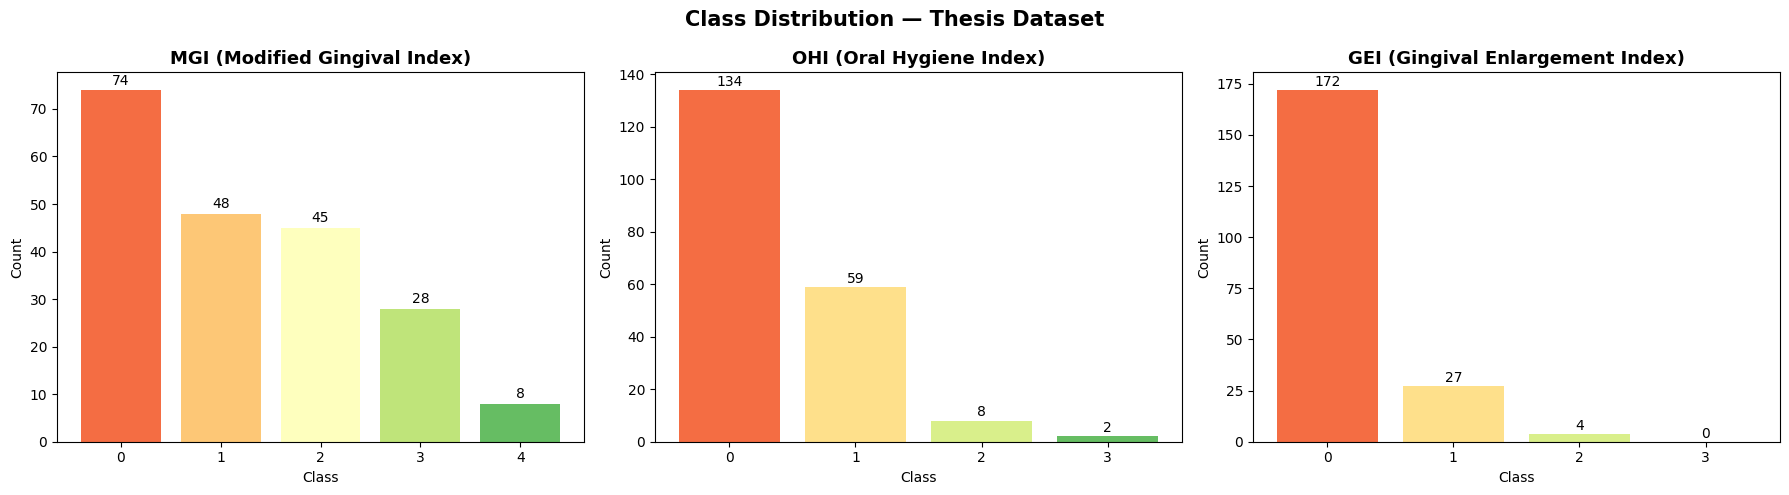


Class weights computed: ['mgi', 'ohi', 'gei']


In [5]:
# ── Label distribution analysis ───────────────────────────────────────────
# Use only one record per patient (avoid triple-counting)
seen_patients = set()
patient_records = []
for r in RECORDS:
    if r['patient_id'] not in seen_patients:
        patient_records.append(r)
        seen_patients.add(r['patient_id'])

df_labels = pd.DataFrame(patient_records)

CLASS_WEIGHTS = {}  # Will be populated below

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

task_info = {
    'mgi': (CONFIG['num_classes_mgi'], 'MGI (Modified Gingival Index)', axes[0]),
    'ohi': (CONFIG['num_classes_ohi'], 'OHI (Oral Hygiene Index)', axes[1]),
    'gei': (CONFIG['num_classes_gei'], 'GEI (Gingival Enlargement Index)', axes[2]),
}

print('\n' + '='*60)
print('LABEL DISTRIBUTION ANALYSIS')
print('='*60)

for task, (n_cls, title, ax) in task_info.items():
    counts = df_labels[task].value_counts().sort_index()
    print(f'\n{title}:')

    for cls in range(n_cls):
        c = counts.get(cls, 0)
        pct = (c / len(df_labels)) * 100
        bar = '█' * int(pct / 2)
        flag = ' ⚠️  UNDERREPRESENTED' if c < 8 else ''
        print(f'  Class {cls}: {c:4d} samples ({pct:5.1f}%) {bar}{flag}')

    # Compute inverse-frequency class weights
    all_labels = df_labels[task].values
    unique_classes = np.sort(df_labels[task].unique())
    raw_weights = compute_class_weight('balanced', classes=unique_classes, y=all_labels)
    weight_map = dict(zip(unique_classes, raw_weights))
    final_weights = np.array([weight_map.get(i, 1.0) for i in range(n_cls)], dtype=np.float32)
    # Cap at 8x to prevent extreme gradients from very rare classes
    final_weights = np.clip(final_weights, None, 8.0)
    CLASS_WEIGHTS[task] = torch.tensor(final_weights, dtype=torch.float32)
    print(f'  Class weights: {[f"{w:.2f}" for w in final_weights]}')

    # Plot
    bars = ax.bar(range(n_cls), [counts.get(i, 0) for i in range(n_cls)],
                  color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, n_cls)))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_xticks(range(n_cls))
    for bar, cls in zip(bars, range(n_cls)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(counts.get(cls, 0)), ha='center', va='bottom', fontsize=10)

plt.suptitle('Class Distribution — Thesis Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'label_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\nClass weights computed: {list(CLASS_WEIGHTS.keys())}')

### Section 4: Data Augmentation
Strong colour augmentation is critical since gingival redness is the primary discriminating feature.


In [6]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

TRAIN_TRANSFORM = A.Compose([
    # Geometric
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=25, p=0.65),
    A.RandomResizedCrop(height=CONFIG['image_size'], width=CONFIG['image_size'],
                        scale=(0.80, 1.0), ratio=(0.85, 1.15), p=0.6),
    A.GridDistortion(num_steps=3, distort_limit=0.2, p=0.2),

    # Colour — important: gingival redness is a key discriminating feature
    A.RandomBrightnessContrast(brightness_limit=0.30, contrast_limit=0.30, p=0.6),
    A.HueSaturationValue(hue_shift_limit=12, sat_shift_limit=35, val_shift_limit=25, p=0.55),
    A.RGBShift(r_shift_limit=20, g_shift_limit=15, b_shift_limit=15, p=0.4),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.06, p=0.4),
    A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.35),

    # Noise / blur
    A.GaussianBlur(blur_limit=(3, 5), p=0.25),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.ImageCompression(quality_lower=70, quality_upper=100, p=0.2),

    # Dropout / occlusion
    A.CoarseDropout(max_holes=4, max_height=28, max_width=28, min_holes=1, p=0.25),

    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

VAL_TRANSFORM = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print('Augmentation pipelines defined.')
print(f'  Train transforms: {len(TRAIN_TRANSFORM.transforms)}')
print(f'  Val transforms:   {len(VAL_TRANSFORM.transforms)}')

Augmentation pipelines defined.
  Train transforms: 16
  Val transforms:   3


### Section 5: Dataset Classes


In [7]:
from torch.utils.data import Dataset, Subset

class MultiViewPatientDataset(Dataset):
    """Returns (frontal, left, right, labels) triplets — one sample per patient."""

    REQUIRED_VIEWS = ('frontal', 'left', 'right')

    def __init__(self, records, transform=None):
        self.transform = transform
        grouped = defaultdict(lambda: {'views': {}})
        for r in records:
            pid = str(r['patient_id'])
            grouped[pid]['patient_id'] = pid
            grouped[pid]['labels'] = {'mgi': r['mgi'], 'ohi': r['ohi'], 'gei': r['gei']}
            grouped[pid]['views'][str(r['view']).lower()] = r['image_path']

        self.samples = []
        for sample in grouped.values():
            if all(v in sample['views'] for v in self.REQUIRED_VIEWS):
                self.samples.append(sample)

        self.samples.sort(key=lambda x: int(x['patient_id']) if x['patient_id'].isdigit() else 0)
        print(f'Dataset: {len(self.samples)} patients with complete 3-view sets')

        self.mgi_labels = [s['labels']['mgi'] for s in self.samples]
        self.ohi_labels = [s['labels']['ohi'] for s in self.samples]
        self.gei_labels = [s['labels']['gei'] for s in self.samples]

    def __len__(self):
        return len(self.samples)

    def _load(self, path):
        """Load, CLAHE-augment, white-balance, and resize image."""
        img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            return np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8)

        img_bgr = cv2.resize(img_bgr, (CONFIG['image_size'], CONFIG['image_size']),
                             interpolation=cv2.INTER_LANCZOS4)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Gray-world white balance
        avg = img_rgb.mean(axis=(0, 1)).astype(np.float32)  # (R, G, B)
        gray_avg = avg.mean()
        scale = np.where(avg > 1e-6, gray_avg / avg, 1.0)
        img_wb = np.clip(img_rgb.astype(np.float32) * scale, 0, 255).astype(np.uint8)

        # CLAHE on L channel
        lab = cv2.cvtColor(img_wb, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_out = cv2.cvtColor(cv2.merge((clahe.apply(l), a, b)), cv2.COLOR_LAB2RGB)
        return img_out

    def __getitem__(self, idx):
        sample = self.samples[idx]
        views = sample['views']
        labels = sample['labels']

        tensors = []
        for v in self.REQUIRED_VIEWS:
            img = self._load(views[v])
            if self.transform is not None:
                img = self.transform(image=img)['image']
            else:
                img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
            tensors.append(img)

        return tensors[0], tensors[1], tensors[2], labels


# Dataset instances
TRAIN_DS = MultiViewPatientDataset(RECORDS, transform=TRAIN_TRANSFORM)
VAL_DS   = MultiViewPatientDataset(RECORDS, transform=VAL_TRANSFORM)
print(f'Dataset size: {len(TRAIN_DS)} patients')

Dataset: 201 patients with complete 3-view sets
Dataset: 201 patients with complete 3-view sets
Dataset size: 201 patients


### Section 6: Loss Function


In [8]:
class FocalLoss(nn.Module):
    """Focal loss — down-weights easy majority-class samples."""

    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        w = self.weight.to(logits.device) if self.weight is not None else None
        ce = F.cross_entropy(logits, targets, weight=w,
                             label_smoothing=self.label_smoothing, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


class OrdinalLoss(nn.Module):
    """Ordinal loss — penalises predictions far from true index on numeric scale."""

    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        ordinal_idx = torch.arange(self.num_classes, device=logits.device).float()
        expected = (probs * ordinal_idx.unsqueeze(0)).sum(dim=1)
        return F.mse_loss(expected, targets.float())


class MultiTaskLoss(nn.Module):
    """Combined weighted-CE + Focal + Ordinal loss with Kendall uncertainty weighting."""

    def __init__(self, class_weights, config):
        super().__init__()
        ls = config.get('label_smoothing', 0.1)
        gamma = config.get('focal_gamma', 2.0)
        n_cls = {
            'mgi': config['num_classes_mgi'],
            'ohi': config['num_classes_ohi'],
            'gei': config['num_classes_gei'],
        }
        self.alpha_ce = config.get('alpha_ce', 1.0)
        self.alpha_focal = config.get('alpha_focal', 0.75)
        self.alpha_ordinal = config.get('alpha_ordinal', 0.5)

        for task in ('mgi', 'ohi', 'gei'):
            w = class_weights.get(task)
            setattr(self, f'ce_{task}',
                nn.CrossEntropyLoss(weight=w, label_smoothing=ls))
            setattr(self, f'focal_{task}',
                FocalLoss(gamma=gamma, weight=w, label_smoothing=ls))
            setattr(self, f'ordinal_{task}',
                OrdinalLoss(n_cls[task]))

        # Kendall learnable log-variances
        self.log_var_mgi = nn.Parameter(torch.zeros(1))
        self.log_var_ohi = nn.Parameter(torch.zeros(1))
        self.log_var_gei = nn.Parameter(torch.zeros(1))

    def _task(self, logits, targets, ce, focal, ordinal, log_var):
        dev = logits.device
        for c in (ce, focal):
            if hasattr(c, 'weight') and c.weight is not None:
                c.weight = c.weight.to(dev)

        raw = (self.alpha_ce    * ce(logits, targets)
             + self.alpha_focal * focal(logits, targets)
             + self.alpha_ordinal * ordinal(logits, targets))
        precision = torch.exp(-log_var)
        weighted = 0.5 * precision * raw + log_var
        return weighted.squeeze(), raw

    def forward(self, preds, targets):
        w_mgi, r_mgi = self._task(preds['mgi'], targets['mgi'],
                                  self.ce_mgi, self.focal_mgi, self.ordinal_mgi, self.log_var_mgi)
        w_ohi, r_ohi = self._task(preds['ohi'], targets['ohi'],
                                  self.ce_ohi, self.focal_ohi, self.ordinal_ohi, self.log_var_ohi)
        w_gei, r_gei = self._task(preds['gei'], targets['gei'],
                                  self.ce_gei, self.focal_gei, self.ordinal_gei, self.log_var_gei)
        return w_mgi + w_ohi + w_gei, {'mgi': r_mgi, 'ohi': r_ohi, 'gei': r_gei}


print('Loss function classes defined.')

Loss function classes defined.


### Section 7: Model Architecture


In [9]:
class _TaskHead(nn.Module):
    """3-layer MLP head with LayerNorm — works well with small batch sizes."""

    def __init__(self, in_features, num_classes, hidden_dim=256, dropout=0.45):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class OralHealthModel(nn.Module):
    """Multi-view DINOv2 model for dental index prediction.

    Shared backbone processes each view, features are concatenated,
    then passed through a shared projection + task-specific heads.
    """

    def __init__(self, config):
        super().__init__()
        backbone_name = config.get('backbone_model', 'vit_small_patch14_dinov2.lvd142m')
        dropout   = float(config.get('dropout', 0.45))
        proj_dim  = int(config.get('projection_dim', 512))
        hidden    = int(config.get('head_hidden_dim', 256))

        self.backbone = timm.create_model(
            backbone_name, pretrained=True, num_classes=0, global_pool='avg'
        )
        backbone_dim = int(self.backbone.num_features)
        print(f'Backbone: {backbone_name} (dim={backbone_dim})')

        fused_dim = backbone_dim * 3  # frontal + left + right
        self.shared_projection = nn.Sequential(
            nn.Linear(fused_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.mgi_head = _TaskHead(proj_dim, config['num_classes_mgi'], hidden, dropout)
        self.ohi_head = _TaskHead(proj_dim, config['num_classes_ohi'], hidden, dropout)
        self.gei_head = _TaskHead(proj_dim, config['num_classes_gei'], hidden, dropout)

        total_trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'Total trainable params: {total_trainable:,}')

    def _feat(self, x):
        f = self.backbone(x)
        return f[0] if isinstance(f, (list, tuple)) else f

    def forward(self, frontal, left, right):
        fused = torch.cat([self._feat(frontal), self._feat(left), self._feat(right)], dim=1)
        shared = self.shared_projection(fused)
        return {'mgi': self.mgi_head(shared),
                'ohi': self.ohi_head(shared),
                'gei': self.gei_head(shared)}

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_last_n_blocks(self, n):
        self.freeze_backbone()
        if n <= 0: return
        blocks = getattr(self.backbone, 'blocks', None)
        if blocks is None:
            for p in self.backbone.parameters(): p.requires_grad = True
            return
        for block in blocks[-n:]:
            for p in block.parameters(): p.requires_grad = True
        for name in ('norm', 'fc_norm'):
            m = getattr(self.backbone, name, None)
            if m is not None:
                for p in m.parameters(): p.requires_grad = True

    def predict_scores(self, frontal, left, right):
        self.eval()
        with torch.no_grad():
            out = self.forward(frontal, left, right)
        result = {}
        for key in ('mgi', 'ohi', 'gei'):
            probs = torch.softmax(out[key].float(), dim=1)
            result[key] = {'score': probs.argmax(dim=1).int(),
                           'confidence': probs.max(dim=1).values * 100,
                           'probs': probs}
        return result


# Quick architecture test
print('\n--- Architecture sanity check ---')
test_model = OralHealthModel(CONFIG)
dummy = torch.zeros(1, 3, CONFIG['image_size'], CONFIG['image_size'])
out = test_model(dummy, dummy, dummy)
print('Output shapes:', {k: v.shape for k, v in out.items()})
del test_model

INFO — Loading pretrained weights from Hugging Face hub (timm/vit_small_patch14_dinov2.lvd142m)



--- Architecture sanity check ---


INFO — HTTP Request: HEAD https://huggingface.co/timm/vit_small_patch14_dinov2.lvd142m/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO — [timm/vit_small_patch14_dinov2.lvd142m] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


RuntimeError: Error(s) in loading state_dict for VisionTransformer:
	Missing key(s) in state_dict: "fc_norm.weight", "fc_norm.bias". 
	Unexpected key(s) in state_dict: "norm.bias", "norm.weight". 

### Section 8: K-Fold Training
Patient-level StratifiedKFold — no data leakage between train and val.


In [ ]:
def build_subset_sampler(dataset, subset_indices):
    """Build WeightedRandomSampler for a subset of indices."""
    mgi_labels = [dataset.samples[i]['labels']['mgi'] for i in subset_indices]
    counts = np.bincount(mgi_labels, minlength=CONFIG['num_classes_mgi']).astype(float)
    counts = np.where(counts == 0, 0.5, counts)
    weights = np.array([1.0 / counts[l] for l in mgi_labels])
    return WeightedRandomSampler(
        torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights), replacement=True
    )


def collect_batch(batch, device):
    frontal, left, right, labels = batch
    targets = {
        'mgi': labels['mgi'].to(device).long(),
        'ohi': labels['ohi'].to(device).long(),
        'gei': labels['gei'].to(device).long(),
    }
    return frontal.to(device), left.to(device), right.to(device), targets


def run_epoch_train(model, loader, optimizer, loss_fn, device, scaler, grad_clip):
    model.train()
    totals = {'total': 0.0, 'mgi': 0.0, 'ohi': 0.0, 'gei': 0.0}
    n = 0
    for batch in loader:
        f, l, r, targets = collect_batch(batch, device)
        optimizer.zero_grad(set_to_none=True)
        use_amp = scaler is not None and device.type == 'cuda'
        with torch.cuda.amp.autocast(enabled=use_amp):
            preds = model(f, l, r)
            total_loss, tl = loss_fn(preds, targets)
        if use_amp:
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer); scaler.update()
        else:
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
        totals['total'] += total_loss.item()
        for k in ('mgi', 'ohi', 'gei'):
            totals[k] += tl[k].item()
        n += 1
    return {k: v/max(n,1) for k, v in totals.items()}


def run_epoch_eval(model, loader, loss_fn, device):
    model.eval()
    y_true = {'mgi': [], 'ohi': [], 'gei': []}
    y_pred = {'mgi': [], 'ohi': [], 'gei': []}
    total_loss = 0.0; n = 0
    with torch.no_grad():
        for batch in loader:
            f, l, r, targets = collect_batch(batch, device)
            preds = model(f, l, r)
            loss, _ = loss_fn(preds, targets)
            total_loss += loss.item(); n += 1
            for k in ('mgi', 'ohi', 'gei'):
                y_pred[k].extend(preds[k].argmax(dim=1).cpu().numpy())
                y_true[k].extend(targets[k].cpu().numpy())
    metrics = {'loss': total_loss/max(n,1)}
    for k in ('mgi', 'ohi', 'gei'):
        t, p = np.array(y_true[k]), np.array(y_pred[k])
        metrics[f'f1_{k}'] = float(f1_score(t, p, average='macro', zero_division=0))
        metrics[f'acc_{k}'] = float(accuracy_score(t, p))
    metrics['avg_f1'] = np.mean([metrics['f1_mgi'], metrics['f1_ohi'], metrics['f1_gei']])
    return metrics, y_true, y_pred


print('Training helper functions defined.')

In [ ]:
# ── Main K-Fold training loop ─────────────────────────────────────────────
all_mgi_labels = np.array(TRAIN_DS.mgi_labels)
n_patients = len(TRAIN_DS)
skf = StratifiedKFold(n_splits=CONFIG['k_folds'], shuffle=True, random_state=CONFIG['seed'])

fold_summaries = []
checkpoint_paths = []
all_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(
    skf.split(np.arange(n_patients), all_mgi_labels), start=1
):
    print(f'\n{'='*70}')
    print(f'  FOLD {fold_idx}/{CONFIG["k_folds"]}  — train={len(train_idx)} val={len(val_idx)}')
    print(f'{'='*70}')

    # ── DataLoaders ──────────────────────────────────────────────────────
    sampler = build_subset_sampler(TRAIN_DS, train_idx)
    train_loader = DataLoader(
        Subset(TRAIN_DS, list(train_idx)),
        batch_size=CONFIG['batch_size'], sampler=sampler,
        num_workers=CONFIG['num_workers'], drop_last=True,
    )
    val_loader = DataLoader(
        Subset(VAL_DS, list(val_idx)),
        batch_size=CONFIG['batch_size'], shuffle=False,
        num_workers=CONFIG['num_workers'],
    )

    # ── Model + Loss ─────────────────────────────────────────────────────
    model = OralHealthModel(CONFIG).to(DEVICE)
    model.freeze_backbone()

    loss_fn = MultiTaskLoss(CLASS_WEIGHTS, CONFIG).to(DEVICE)

    head_params = (
        list(model.shared_projection.parameters())
        + list(model.mgi_head.parameters())
        + list(model.ohi_head.parameters())
        + list(model.gei_head.parameters())
        + list(loss_fn.parameters())
    )
    optimizer = torch.optim.AdamW(head_params, lr=CONFIG['lr_heads'],
                                   weight_decay=CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=CONFIG['scheduler_T0'], eta_min=1e-7
    )
    scaler = amp.GradScaler() if DEVICE.type == 'cuda' else None

    ckpt_path = Path(CONFIG['checkpoint_dir']) / f'checkpoint_fold_{fold_idx}.pth'
    best_f1 = 0.0
    patience_counter = 0
    fold_history = []

    # ── Epoch loop ───────────────────────────────────────────────────────
    for epoch in range(1, CONFIG['num_epochs'] + 1):

        # Phase 2: unfreeze backbone
        if epoch == CONFIG['freeze_epochs'] + 1:
            model.unfreeze_last_n_blocks(CONFIG['unfreeze_blocks'])
            backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
            head_params_new = (
                list(model.shared_projection.parameters())
                + list(model.mgi_head.parameters())
                + list(model.ohi_head.parameters())
                + list(model.gei_head.parameters())
                + list(loss_fn.parameters())
            )
            optimizer = torch.optim.AdamW([
                {'params': backbone_params, 'lr': CONFIG['lr_backbone']},
                {'params': list(model.shared_projection.parameters()),
                 'lr': CONFIG['lr_projection']},
                {'params': (list(model.mgi_head.parameters())
                          + list(model.ohi_head.parameters())
                          + list(model.gei_head.parameters())
                          + list(loss_fn.parameters())),
                 'lr': CONFIG['lr_heads']},
            ], weight_decay=CONFIG['weight_decay'])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer, T_0=CONFIG['scheduler_T0'], eta_min=1e-7
            )
            trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f'  ↳ Epoch {epoch}: Phase-2 backbone unfrozen '
                  f'(last {CONFIG["unfreeze_blocks"]} blocks). '
                  f'Trainable params: {trainable:,}')

        train_m = run_epoch_train(
            model, train_loader, optimizer, loss_fn, DEVICE,
            scaler, CONFIG['grad_clip_norm']
        )
        val_m, vt, vp = run_epoch_eval(model, val_loader, loss_fn, DEVICE)
        scheduler.step()

        row = {
            'epoch': epoch,
            'train_loss': train_m['total'],
            **{f'val_{k}': v for k, v in val_m.items()},
        }
        fold_history.append(row)

        avg_f1 = val_m['avg_f1']
        print(f'  Ep {epoch:02d} train={train_m["total"]:.4f} '
              f'val_f1(mgi/ohi/gei)=({val_m["f1_mgi"]:.3f}/'
              f'{val_m["f1_ohi"]:.3f}/{val_m["f1_gei"]:.3f}) '
              f'avg={avg_f1:.3f}', end='')

        if avg_f1 > best_f1:
            best_f1 = avg_f1
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss_fn_state_dict': loss_fn.state_dict(),
                'best_val_f1': best_f1,
                'config': CONFIG,
            }, ckpt_path)
            print(f'  ✓ saved (best_f1={best_f1:.4f})')
        else:
            patience_counter += 1
            print(f'  (patience {patience_counter}/{CONFIG["early_stopping_patience"]})')
            if patience_counter >= CONFIG['early_stopping_patience']:
                print(f'  Early stopping at epoch {epoch}')
                break

    checkpoint_paths.append(str(ckpt_path))
    all_histories.append(fold_history)

    # Reload best and report
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
    final_m, _, _ = run_epoch_eval(model, val_loader, loss_fn, DEVICE)

    fold_summaries.append({
        'fold': fold_idx, 'best_val_f1': best_f1, 'checkpoint': str(ckpt_path),
        'final_acc_mgi': final_m['acc_mgi'],
        'final_acc_ohi': final_m['acc_ohi'],
        'final_acc_gei': final_m['acc_gei'],
        'final_f1_mgi': final_m['f1_mgi'],
        'final_f1_ohi': final_m['f1_ohi'],
        'final_f1_gei': final_m['f1_gei'],
    })
    print(f'\n  Fold {fold_idx} summary → best_f1={best_f1:.4f} '
          f'acc(mgi/ohi/gei)=({final_m["acc_mgi"]:.3f}/{final_m["acc_ohi"]:.3f}/{final_m["acc_gei"]:.3f})')

print('\n' + '='*70)
print('K-FOLD TRAINING COMPLETE')
print('='*70)

### Section 9: Summary Statistics


In [ ]:
df_summary = pd.DataFrame(fold_summaries)
print('\nFold-level Results:')
print(df_summary.to_string(index=False))

print('\nMean ± Std across folds:')
for col in ['best_val_f1', 'final_f1_mgi', 'final_f1_ohi', 'final_f1_gei',
            'final_acc_mgi', 'final_acc_ohi', 'final_acc_gei']:
    vals = df_summary[col]
    print(f'  {col:25s}: {vals.mean():.4f} ± {vals.std():.4f}')

### Section 10: Export Ensemble Config


In [ ]:
import json

avg_f1 = {
    'mgi': float(df_summary['final_f1_mgi'].mean()),
    'ohi': float(df_summary['final_f1_ohi'].mean()),
    'gei': float(df_summary['final_f1_gei'].mean()),
}

ensemble_cfg = {
    'models': checkpoint_paths,
    'weights': [1.0] * len(checkpoint_paths),
    'config': CONFIG,
    'avg_val_f1': avg_f1,
}

# Save to both checkpoints/ and models/ root (backend reads from models/)
for save_path in [
    Path(CONFIG['checkpoint_dir']) / 'ensemble_config.json',
    Path(CONFIG['checkpoint_dir']).parent / 'ensemble_config.json',
]:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, 'w') as f:
        json.dump(ensemble_cfg, f, indent=2)
    print(f'Ensemble config saved → {save_path}')

# PI calibration placeholder (real value computed from actual tooth images)
pi_calib = {
    'mean_brightness': 128.0,
    'mean_contrast': 40.0,
    'mean_temp': 5.0,
    'note': 'Placeholder — recompute using compute_pi_calibration_reference() after inference pipeline is set up'
}
pi_path = Path(CONFIG['checkpoint_dir']).parent / 'pi_calibration.json'
with open(pi_path, 'w') as f:
    json.dump(pi_calib, f, indent=2)
print(f'PI calibration placeholder saved → {pi_path}')

### Section 11: Visualisation


In [ ]:
# ── Loss curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for fold_i, history in enumerate(all_histories):
    epochs = [h['epoch'] for h in history]
    train_loss = [h['train_loss'] for h in history]
    val_loss   = [h['val_loss'] for h in history]
    avg_f1     = [h['val_avg_f1'] for h in history]

    axes[0, 0].plot(epochs, train_loss, label=f'Fold {fold_i+1}')
    axes[0, 1].plot(epochs, val_loss, label=f'Fold {fold_i+1}')
    axes[0, 2].plot(epochs, avg_f1, label=f'Fold {fold_i+1}')

for ax, title in zip(axes[0], ['Train Loss', 'Val Loss', 'Val Avg Macro-F1']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Confusion matrices for best fold ───────────────────────────────────────
best_fold_idx = np.argmax([s['best_val_f1'] for s in fold_summaries])
best_ckpt_path = fold_summaries[best_fold_idx]['checkpoint']

# Reload best fold model
_, val_idx_best = list(skf.split(np.arange(n_patients), all_mgi_labels))[best_fold_idx]
val_loader_best = DataLoader(
    Subset(VAL_DS, list(val_idx_best)),
    batch_size=CONFIG['batch_size'], shuffle=False,
)
model_best = OralHealthModel(CONFIG).to(DEVICE)
ckpt_data = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
model_best.load_state_dict(ckpt_data['model_state_dict'])
loss_fn_reloaded = MultiTaskLoss(CLASS_WEIGHTS, CONFIG).to(DEVICE)
_, yt_best, yp_best = run_epoch_eval(model_best, val_loader_best, loss_fn_reloaded, DEVICE)

class_configs = {
    'MGI (0-4)': (range(5), 'mgi', axes[1, 0]),
    'OHI (0-3)': (range(4), 'ohi', axes[1, 1]),
    'GEI (0-3)': (range(4), 'gei', axes[1, 2]),
}
for title, (labels, task, ax) in class_configs.items():
    cm = confusion_matrix(yt_best[task], yp_best[task], labels=list(labels))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=list(labels), yticklabels=list(labels))
    ax.set_title(f'{title} — Best Fold Confusion Matrix (normalised)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Training Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'training_results.png'), dpi=150, bbox_inches='tight')
plt.show()

# Classification reports
for task in ('mgi', 'ohi', 'gei'):
    print(f'\n--- {task.upper()} Classification Report (Best Fold) ---')
    print(classification_report(yt_best[task], yp_best[task], zero_division=0))

### Section 12: Backend Integration Check


In [ ]:
# Verify ensemble_config.json is readable and models load correctly
models_root = Path(CONFIG['checkpoint_dir']).parent
ensemble_config_path = models_root / 'ensemble_config.json'

print('=== Backend Integration Check ===')
print(f'ensemble_config.json: {ensemble_config_path}')

if ensemble_config_path.exists():
    with open(ensemble_config_path) as f:
        ec = json.load(f)
    print(f'Model paths: {ec["models"]}')
    print(f'Avg val F1: {ec["avg_val_f1"]}')

    for mp in ec['models']:
        exists = os.path.exists(mp)
        icon = '✓' if exists else '✗ MISSING'
        print(f'  {icon} {mp}')

    print('\nAttempting to load first fold model...')
    try:
        test_load = OralHealthModel(ec['config']).to('cpu')
        ckpt = torch.load(ec['models'][0], map_location='cpu', weights_only=False)
        test_load.load_state_dict(ckpt['model_state_dict'])
        test_load.eval()
        dummy = torch.zeros(1, 3, ec['config']['image_size'], ec['config']['image_size'])
        out = test_load(dummy, dummy, dummy)
        print('✓ Model loaded and forward pass successful.')
        print('  Output shapes:', {k: v.shape for k, v in out.items()})
    except Exception as e:
        print(f'✗ Load failed: {e}')
else:
    print('✗ ensemble_config.json not found. Run training first.')

print('\nTraining notebook complete. Ready for backend inference.')